<h1>Group 34 - Assignment 2</h1>
<h3>Dora Khoshimova, Sevval Yelmer </h3>

<h1> Random Forest Model </h1>

<h2>1. Installing Libraries</h2>

In [36]:
%pip install pandas numpy scikit-learn shap lime opencv-python scikit-image matplotlib
%pip install kagglehub pandas opencv-python numpy scikit-learn tensorflow
%pip install torch torchvision torchaudio
%pip install interpret

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [37]:
# General Dependecies
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
import kagglehub

# Dependecies for Random Forest Classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report


# Dependecies for Explanaible Algorithms
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
import shap
import lime
from lime import lime_image
from lime.lime_tabular import LimeTabularExplainer
from skimage.segmentation import mark_boundaries

<h2>2. Dataset prep </h2>

In [38]:
# Calling the path and joining it to a csv file
path = kagglehub.dataset_download("faysalmiah1721758/breast-cancer-data")
csv_path = os.path.join(path, "breast-cancer-data.csv")
data = pd.read_csv(csv_path)

# Printing information to see if we were able to load the dataset correctly
#print(data.head)
# data.info()
# data.shape 
# data.describe(include="object")

data.isnull().sum() # these are the missing values, they will be removed later


age            0
menopause      0
tumer-size     0
inv-nodes      0
node-caps      8
deg-malig      0
breast         0
breast-quad    1
irradiate      0
class          0
dtype: int64

<h3>a. Dropping the missing values</h3>

In [39]:
# To ensure that we do not have any missing values, we decided to remove them

data.dropna(subset=["node-caps", "breast-quad"], inplace=True)
data.isnull().sum() # now all of them is supposed to be a 0 because we dropped the missing values


age            0
menopause      0
tumer-size     0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiate      0
class          0
dtype: int64

<h3>b. Label Encoding</h3>

In [40]:
# Since the dataset had different values such as strings, float and integers, we decided to turn everything into int
label_encoder = LabelEncoder()
data["age"] = label_encoder.fit_transform(data["age"])
data["menopause"] = label_encoder.fit_transform(data["menopause"])
data["tumer-size"] = label_encoder.fit_transform(data["tumer-size"])
data["inv-nodes"] = label_encoder.fit_transform(data["inv-nodes"])
data["node-caps"] = label_encoder.fit_transform(data["node-caps"])
data["deg-malig"] = label_encoder.fit_transform(data["deg-malig"])
data["breast"] = label_encoder.fit_transform(data["breast"])
data["breast-quad"] = label_encoder.fit_transform(data["breast-quad"])
data["irradiate"] = label_encoder.fit_transform(data["irradiate"])
data["class"] = label_encoder.fit_transform(data["class"])

data.head


<bound method NDFrame.head of      age  menopause  tumer-size  inv-nodes  node-caps  deg-malig  breast  \
0      2          2           2          0          1          2       1   
1      3          0           2          0          0          0       1   
2      3          0           6          0          0          1       0   
3      2          2           6          0          1          2       1   
4      2          2           5          4          1          1       0   
..   ...        ...         ...        ...        ...        ...     ...   
281    3          0           5          5          1          1       0   
282    3          2           4          4          1          1       0   
283    1          2           5          5          1          1       1   
284    3          2           2          0          0          1       1   
285    3          0           7          0          0          2       0   

     breast-quad  irradiate  class  
0              2    

<h3>c. Splitting the data </h3>

In [41]:
X = data.drop("class", axis=1)
y = data["class"]

X = pd.get_dummies(X, drop_first=True)


In [42]:
# Splitting the data in 30/70 ratio, we decided to go wth 30/70 instead of 20/80 because the dataset is not balanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=9)

In [43]:
"""from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

gr_space = {
    "max_depth": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "n_estimators": [100, 200, 300, 400, 500],
    "max_features": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 4],
}

rf = RandomForestClassifier(class_weight="balanced", random_state=42)

grid_search = GridSearchCV(
    rf, param_grid=gr_space, cv=5, scoring="f1_macro", verbose=3, n_jobs=-1
)

model_grid = grid_search.fit(X_train, y_train)

print("Best hyperparameters are " + str(model_grid.best_params_))
print("Best score is: " + str(model_grid.best_score_))
"""

'from sklearn.model_selection import GridSearchCV\nfrom sklearn.ensemble import RandomForestClassifier\n\ngr_space = {\n    "max_depth": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],\n    "n_estimators": [100, 200, 300, 400, 500],\n    "max_features": [2, 4, 6, 8, 10],\n    "min_samples_leaf": [1, 2, 4],\n}\n\nrf = RandomForestClassifier(class_weight="balanced", random_state=42)\n\ngrid_search = GridSearchCV(\n    rf, param_grid=gr_space, cv=5, scoring="f1_macro", verbose=3, n_jobs=-1\n)\n\nmodel_grid = grid_search.fit(X_train, y_train)\n\nprint("Best hyperparameters are " + str(model_grid.best_params_))\nprint("Best score is: " + str(model_grid.best_score_))\n'

<h2>3. Running the Random Forest model </h2>

In [44]:
model = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced", random_state=42
)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

<h2> Analyzing the outcome of the model </h2>

In [45]:
y_pred = model.predict(X_test)

#print(y_pred)

print(f"Accuracy score is: {accuracy_score(y_test, y_pred)}")
print(f'F1 score is: {f1_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

Accuracy score is: 0.7261904761904762
F1 score is: 0.4888888888888889
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        61
           1       0.50      0.48      0.49        23

    accuracy                           0.73        84
   macro avg       0.65      0.65      0.65        84
weighted avg       0.72      0.73      0.72        84



LIME
--


In [ ]:
from IPython.display import display, HTML

# create lime explainer for the x_train data and the model we trained, we will use it to explain the predictions of the model on the x_test data
lime_explainer = LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = X_train.columns,
    class_names = ["no-recurrence-events", "recurrence-events"],
    verbose = True,
    discretize_continuous = True, # we set discretize continuous to true to make it easier for the explainer to explain the predictions
    mode = "classification",
    random_state = 42 # to ensure that we get the same results every time we run the code, we set the random state to 42
)

idx = 0 # index of feature we want explained
instance = X_test.values[idx] 

# call the explainer to explain the prediction on the instance at idx we set
explanation = lime_explainer.explain_instance(
    instance, 
    model.predict_proba, # predict_proba is used for classification problems
    num_features = 9, # top 9 features (minus the "class" feature)
    labels = [0, 1]
)

# explanation.show_in_notebook(show_table = True) 
display(HTML(explanation.as_html())) # not readable with dark mode

# alternative plot to show the explanation in a more readable way
true_label = y_test.values[idx]
pred_label = int(model.predict([instance])[0]) # convert numpy int to python int 

fig = explanation.as_pyplot_figure(label=int(pred_label))
plt.title(f"True label: {true_label}, Predicted label: {pred_label}")
plt.show()

# print(explanation.available_labels()) didn't work 

all_weights = []

for x in range(20): # explain the first 20 instances in the test set
    exp = lime_explainer.explain_instance( 
        X_test.values[x], # explain the instance at index x in the test set
        model.predict_proba,
        num_features=10,
        labels=[0, 1]
    )
    pred = model.predict([X_test.values[x]])[0] # get the predicted label for the instance at index x
    weights = dict(exp.as_list(label=int(pred))) # get the weights for the predicted label and convert it to a dictionary
    all_weights.append(weights)

weights_df = pd.DataFrame(all_weights).fillna(0) # create dataframe from weights, missing values are filled with 0

abs_mean = weights_df.abs().mean().sort_values(ascending=False) # calculate mean absolute weight for each feature and sort descending order

plt.figure(figsize=(10, 6))
plt.barh(abs_mean.head(10).index, abs_mean.head(10).values)
plt.gca().invert_yaxis() # invert y-axis so feature with highest mean absolute weight is at the top
plt.xlabel("Mean absolute LIME weight")
plt.title("Top 10 features by mean LIME weight (first 20 test instances)")
plt.show()


print("top 10 features by mean abs LIME weight table:")
print(mean_abs_weights.head(10).to_string())

SHAP
--

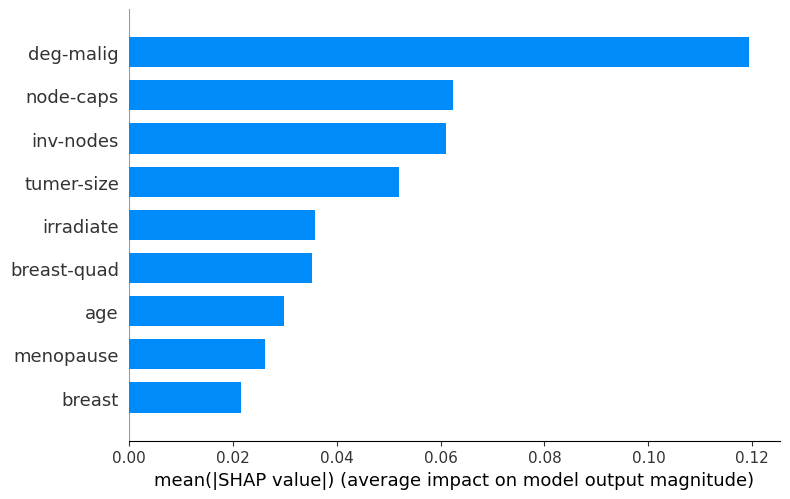

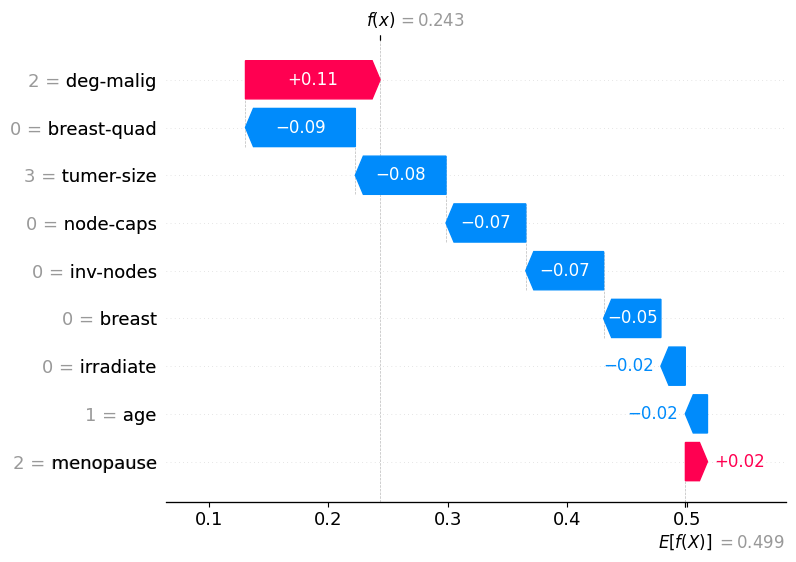

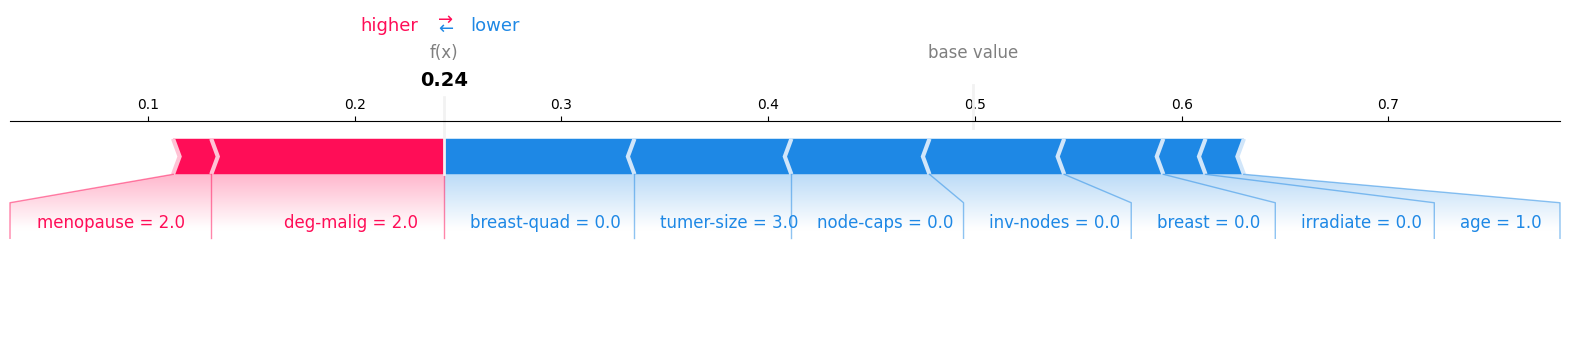

In [61]:
shap_explainer = shap.TreeExplainer(model)
shap_values = shap_explainer.shap_values(X_test)
shap.summary_plot(
    shap_values[:, :, 1], # shap values for the class 1 (recurrence-events)
    X_test, 
    feature_names=X_train.columns.to_list(), 
    plot_type="bar"
    )

# explaination for first instance in test set in waterfall plot
idx = 0
shap_explanation = shap.Explanation(
    values=shap_values[idx, :, 1], 
    base_values=shap_explainer.expected_value[1], 
    data=X_test.values[idx], 
    feature_names=X_train.columns.to_list()
    )
shap.waterfall_plot(shap_explanation)

# force plot for the first instance in the test set
shap.force_plot(shap_explanation, matplotlib=True) 


<h1> Explainable Boosting Classifier </h1>

In [31]:
ebm = ExplainableBoostingClassifier(random_state=42)

ebm.fit(X_train, y_train)

y_pred_ebm = ebm.predict(X_test)
print(f"EBM Accuracy: {accuracy_score(y_test, y_pred_ebm)}")
print(classification_report(y_test, y_pred_ebm))


EBM Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        61
           1       0.48      0.43      0.45        23

    accuracy                           0.71        84
   macro avg       0.63      0.63      0.63        84
weighted avg       0.71      0.71      0.71        84



In [ ]:
ebm_global = ebm.explain_global()
show(ebm_global)
ebm_local = ebm.explain_local(X_test[:5], y_test[:5])
show(ebm_local)
